In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import os

sns.set_theme(style="whitegrid", palette="husl")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
 
os.makedirs('../reports', exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


In [29]:
df = pd.read_csv('../data/raw/diabetes.csv')

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

print(f"Dataset loaded Shape: {df.shape}")
df.head()

PermissionError: [Errno 1] Operation not permitted: '../data/raw/diabetes.csv'

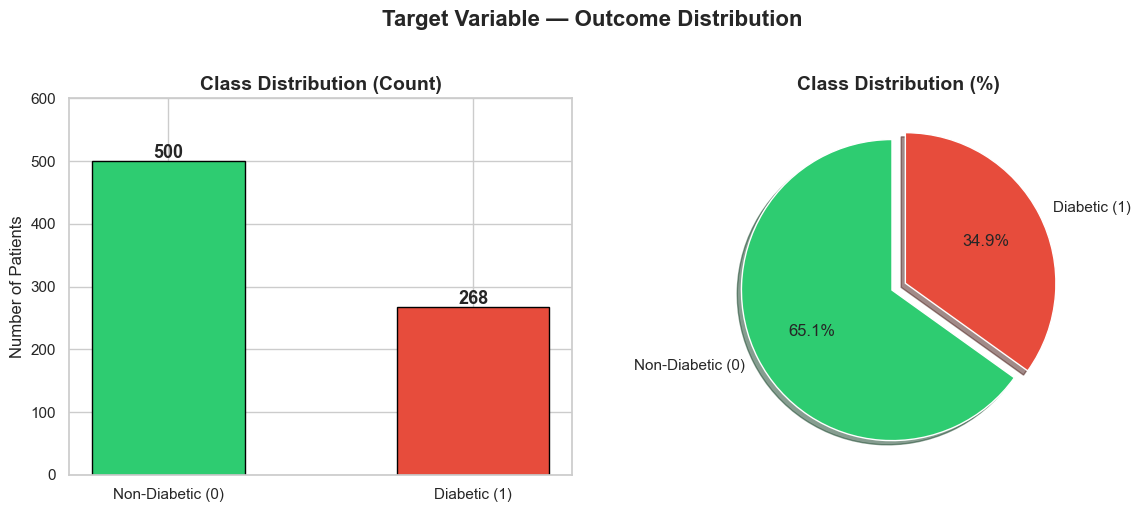

Plot saved to reports/01_class_distribution.png


In [ ]:
# PLOT 1: Class Distribution (Diabetic vs Non-Diabetic)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

outcome_counts = df['Outcome'].value_counts()
bars = axes[0].bar(
    ['Non-Diabetic (0)', 'Diabetic (1)'],
    outcome_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.5
)

for bar, count in zip(bars, outcome_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center', fontweight='bold', fontsize=13
    )
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, 600)

axes[1].pie(
    outcome_counts.values,
    labels=['Non-Diabetic (0)', 'Diabetic (1)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    explode=(0.05, 0.05),
    shadow=True,
    startangle=90
)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable — Outcome Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to reports/01_class_distribution.png")

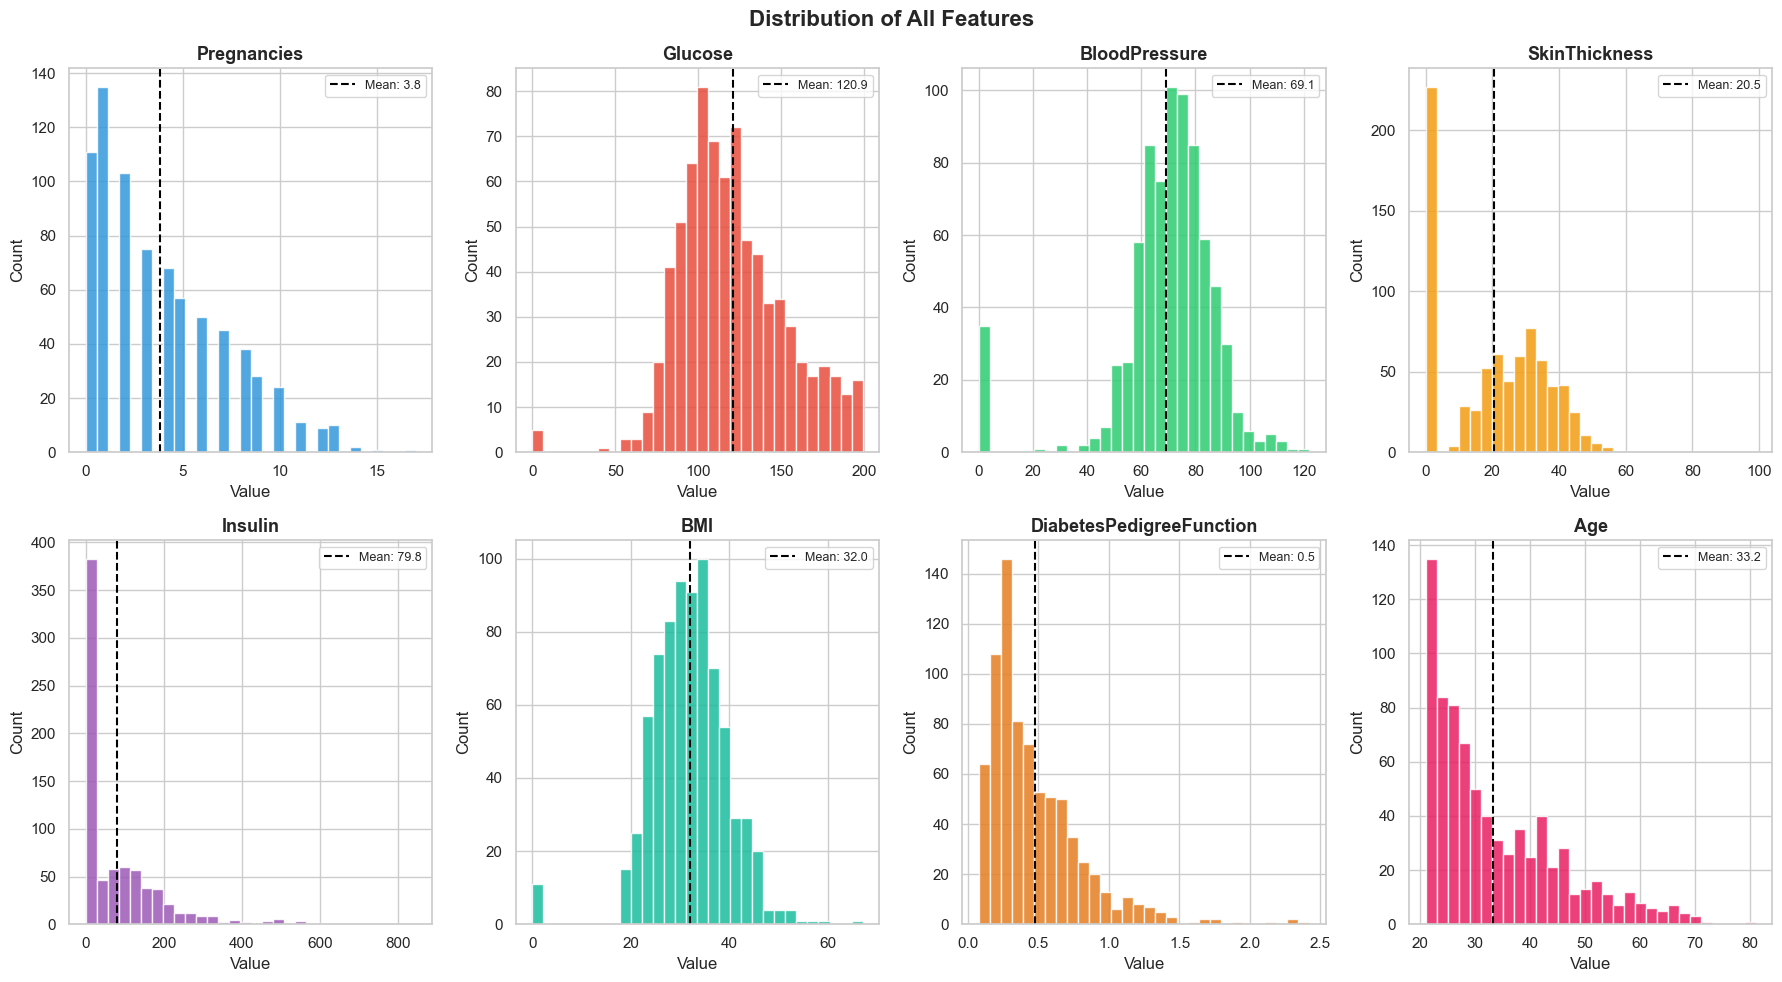

Plot saved to reports/02_feature_distributions.png


In [ ]:
# PLOT 2: Distribution of all 8 features

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()  # Convert 2D array to 1D for easy looping

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22', '#e91e63']

for i, feature in enumerate(features):
    axes[i].hist(
        df[feature],
        bins=30,
        color=colors[i],
        edgecolor='white',
        alpha=0.85
    )
    axes[i].set_title(f'{feature}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

    # Add a vertical line at mean
    mean_val = df[feature].mean()
    axes[i].axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to reports/02_feature_distributions.png")

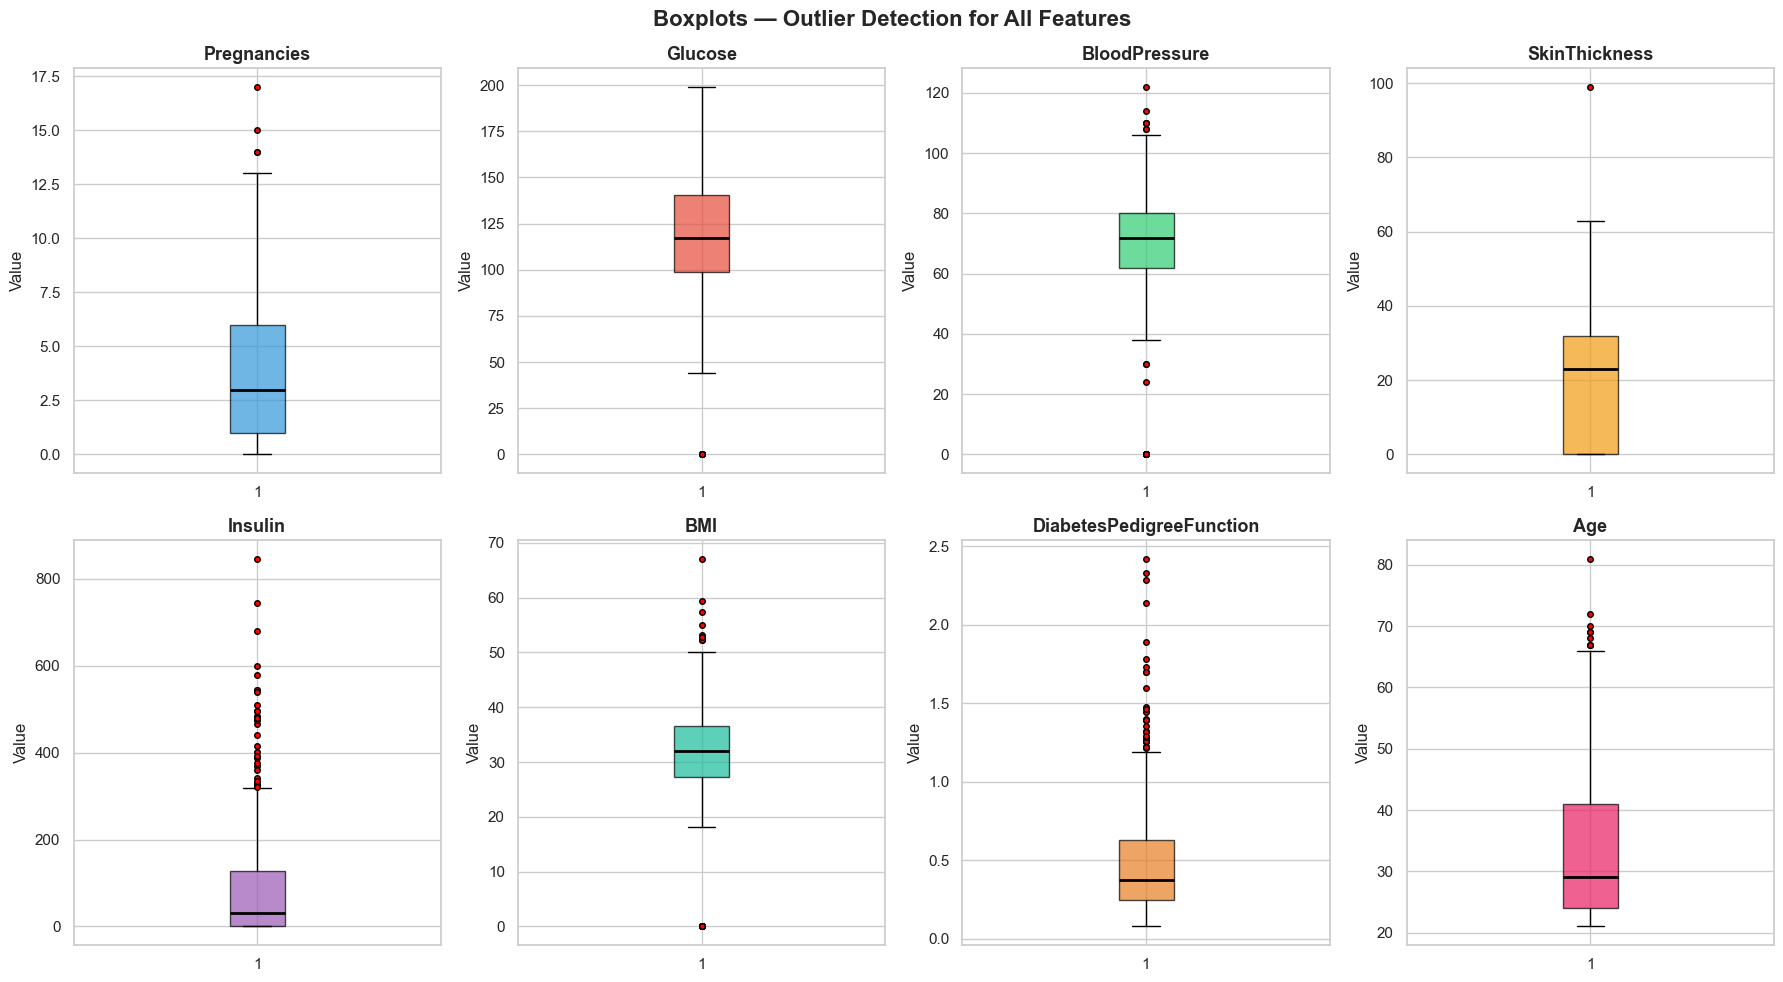

Plot saved to reports/03_boxplots_outliers.png


In [ ]:
# PLOT 3: Boxplots for each feature

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].boxplot(
        df[feature],
        patch_artist=True,
        boxprops=dict(facecolor=colors[i], alpha=0.7),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='red', markersize=4)
    )
    axes[i].set_title(f'{feature}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection for All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to reports/03_boxplots_outliers.png")

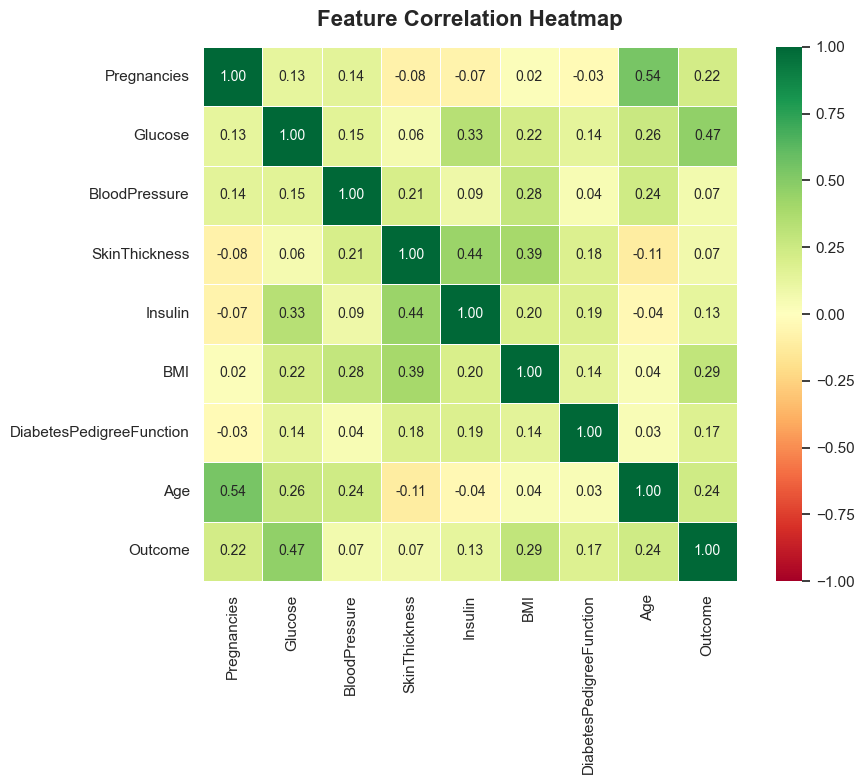

Plot saved to reports/04_correlation_heatmap.png


In [ ]:
# PLOT 4: Correlation Heatmap


plt.figure(figsize=(10, 8))

corr_matrix = df.corr()

# Create heatmap
sns.heatmap(
    corr_matrix,
    annot=True,          
    fmt='.2f',           
    cmap='RdYlGn',        
    linewidths=0.5,
    square=True,
    vmin=-1, vmax=1,
    annot_kws={'size': 10}
)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to reports/04_correlation_heatmap.png")

In [ ]:
# PLOT 5: Interactive Scatter Plot (Plotly)

plot_df = df.copy()
plot_df['Outcome_Label'] = plot_df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

fig = px.scatter(
    plot_df,
    x='Glucose',
    y='BMI',
    color='Outcome_Label',
    size='Age',
    hover_data=['Age', 'Insulin', 'BloodPressure'],
    color_discrete_map={'Non-Diabetic': '#2ecc71', 'Diabetic': '#e74c3c'},
    title='Interactive: Glucose vs BMI (sized by Age)',
    labels={'Glucose': 'Glucose Level', 'BMI': 'Body Mass Index'}
)

fig.update_layout(
    title_font_size=16,
    legend_title='Diagnosis',
    height=550
)

fig.show()
print("Interactive chart displayed")

Interactive chart displayed


In [30]:

print("                    EDA VISUAL SUMMARY")

print()
print("Plots generated and saved to /reports/:")
plots = [
    "01_class_distribution.png  → Class imbalance confirmed",
    "02_feature_distributions.png → Zeros visible in Insulin/Skin",
    "03_boxplots_outliers.png   → Outliers found in Insulin/BMI",
    "04_correlation_heatmap.png → Glucose most correlated feature"
]
for p in plots:
    print(f"  {p}")

print()
print("Key Insights:")
print("  1. Glucose is the strongest predictor of diabetes")
print("  2. BMI and Age are also important features")
print("  3. Insulin & SkinThickness have too many zeros (missing)")
print("  4. Class imbalance: 65% Non-Diabetic vs 35% Diabetic")
print("  5. Several outliers present, especially in Insulin")
print()
print("All issues will be addressed in Phase 4: Preprocessing")


                    EDA VISUAL SUMMARY

Plots generated and saved to /reports/:
  01_class_distribution.png  → Class imbalance confirmed
  02_feature_distributions.png → Zeros visible in Insulin/Skin
  03_boxplots_outliers.png   → Outliers found in Insulin/BMI
  04_correlation_heatmap.png → Glucose most correlated feature

Key Insights:
  1. Glucose is the strongest predictor of diabetes
  2. BMI and Age are also important features
  3. Insulin & SkinThickness have too many zeros (missing)
  4. Class imbalance: 65% Non-Diabetic vs 35% Diabetic
  5. Several outliers present, especially in Insulin

All issues will be addressed in Phase 4: Preprocessing
